# Improved Multi-Class Text Classification
This notebook implements multiple strategies to improve classification performance:
- Reduced number of categories (only well-represented ones)
- Class balancing with proper sampling
- Better model architecture (SciBERT for academic text)
- Focal loss for handling imbalance
- Label cleaning with confidence scores
- Hierarchical classification option

In [1]:
# Install required packages
!pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn tqdm cleanlab pyarrow

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    AutoModel,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Load and Filter Data

In [3]:
# Path to parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

# Load the parquet file
df = pd.read_parquet(PARQUET_FILE_PATH)

print(f"Original data shape: {df.shape}")
print(f"Columns in dataset: {df.columns.tolist()}")

# Rename columns for consistency with the rest of the notebook
df = df.rename(columns={
    'primary_subject': 'category',
    'abstract': 'text'
})

print(f"\nColumns after renaming: {df.columns.tolist()}")
print(f"\nSample text (first 500 chars):")
print(df['text'].iloc[0][:500] + "...")

print(f"\nOriginal number of categories: {df['category'].nunique()}")

# Show category distribution
category_counts = df['category'].value_counts()
print(f"\nCategory distribution:")
print(f"Min samples per category: {category_counts.min()}")
print(f"Max samples per category: {category_counts.max()}")
print(f"Median samples per category: {category_counts.median()}")
print(f"Mean samples per category: {category_counts.mean():.1f}")
print(f"\nTop 10 most common categories:")
print(category_counts.head(10))
print(f"\nBottom 10 least common categories:")
print(category_counts.tail(10))

Original data shape: (2549619, 10)
Columns in dataset: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path']

Columns after renaming: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'category', 'subjects', 'doi', 'text', 'file_path']

Sample text (first 500 chars):
Stars on eccentric orbits around a massive black hole (MBH) emit bursts of gravitational waves (GWs) at periapse. Such events may be directly resolvable in the Galactic centre. However, if the star does not spiral in, the emitted GWs are not resolvable for extra-galactic MBHs, but constitute a source of background noise. We estimate the power spectrum of this extreme mass ratio burst background (EMBB) and compare it to the anticipated instrumental noise of the Laser Interferometer Space Antenna ...

Original number of categories: 148

Category distribution:
Min samples per category: 112
Max samples per category: 120122
Median samples per

In [4]:
# Filter categories with sufficient samples and balance dataset
MIN_SAMPLES_PER_CATEGORY = 50  # Minimum to consider a category
MAX_SAMPLES_PER_CATEGORY = 100  # Maximum samples to use per category (for quick testing)

# Get categories with enough samples
valid_categories = category_counts[category_counts >= MIN_SAMPLES_PER_CATEGORY].index.tolist()
print(f"Categories with >= {MIN_SAMPLES_PER_CATEGORY} samples: {len(valid_categories)}")

# Sample up to MAX_SAMPLES_PER_CATEGORY from each valid category
balanced_dfs = []
for category in valid_categories:
    cat_df = df[df['category'] == category]
    n_samples = min(len(cat_df), MAX_SAMPLES_PER_CATEGORY)
    balanced_dfs.append(cat_df.sample(n=n_samples, random_state=42))

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(f"Number of categories: {df_balanced['category'].nunique()}")
print(f"Samples per category:")
print(df_balanced['category'].value_counts().describe())

Categories with >= 50 samples: 148

Balanced dataset shape: (14800, 10)
Number of categories: 148
Samples per category:
count    148.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64


## 2. Prepare Data with Label Encoding

In [5]:
# Encode labels
label_encoder = LabelEncoder()
df_balanced['label'] = label_encoder.fit_transform(df_balanced['category'])
num_classes = len(label_encoder.classes_)

print(f"Number of classes: {num_classes}")

# Create label mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nSample label mappings:")
for k, v in list(label_mapping.items())[:5]:
    print(f"  {k}: {v}")

Number of classes: 148

Sample label mappings:
  Accelerator Physics (physics.acc-ph): 0
  Adaptation and Self-Organizing Systems (nlin.AO): 1
  Algebraic Geometry (math.AG): 2
  Algebraic Topology (math.AT): 3
  Analysis of PDEs (math.AP): 4


In [6]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'].values,
    df_balanced['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

# Further split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Train set size: 10064
Validation set size: 1776
Test set size: 2960


## 3. Custom Dataset and Focal Loss

In [7]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [8]:
class FocalLoss(nn.Module):
    """Focal Loss for addressing class imbalance"""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            if self.alpha.device != focal_loss.device:
                self.alpha = self.alpha.to(focal_loss.device)
            focal_loss = self.alpha[targets] * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## 4. Initialize Model with Better Architecture

In [9]:
# Use local SciBERT model
MODEL_NAME = './models/scibert_scivocab_uncased'  # Local model path
# Alternative options if you want to try different models:
# MODEL_NAME = 'roberta-base'  # Good general performance (would download)
# MODEL_NAME = 'microsoft/deberta-v3-base'  # State-of-the-art (would download)

print(f"Loading model from local path: {MODEL_NAME}")

# Load tokenizer from local model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    
print(f"✓ Tokenizer loaded successfully")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Loading model from local path: ./models/scibert_scivocab_uncased
✓ Tokenizer loaded successfully
Vocabulary size: 31090


In [10]:
class ImprovedClassifier(nn.Module):
    """Improved classifier with dropout and better architecture"""
    def __init__(self, model_name, num_classes, dropout_rate=0.3):
        super().__init__()
        # Load from local path
        self.bert = AutoModel.from_pretrained(model_name, local_files_only=True)
        self.hidden_size = self.bert.config.hidden_size
        
        # Improved classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.ReLU(),
            nn.LayerNorm(self.hidden_size // 2),
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size // 2, num_classes)
        )
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits
    
    def get_embeddings(self, input_ids, attention_mask):
        """Get embeddings for label cleaning"""
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state[:, 0]

## 5. Training Setup with Class Weights

In [11]:
# Calculate class weights for handling imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Initialize model
model = ImprovedClassifier(MODEL_NAME, num_classes).to(device)

# Create datasets
train_dataset = TextDataset(X_train, y_train, tokenizer)
val_dataset = TextDataset(X_val, y_val, tokenizer)
test_dataset = TextDataset(X_test, y_test, tokenizer)

# Create dataloaders with weighted sampling for training
train_sample_weights = [class_weights[label].item() for label in y_train]
train_sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
# Training configuration
EPOCHS = 10  # Adjust based on your time constraints
LEARNING_RATE = 2e-5
WARMUP_STEPS = 500

# Loss function with class weights
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

# Optimizer with different learning rates for different layers
bert_params = list(model.bert.parameters())
classifier_params = list(model.classifier.parameters())

optimizer = torch.optim.AdamW([
    {'params': bert_params, 'lr': LEARNING_RATE},
    {'params': classifier_params, 'lr': LEARNING_RATE * 10}  # Higher LR for classifier
], weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

## 6. Training Loop with Early Stopping

In [13]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(dataloader), correct / total, all_predictions, all_labels

In [14]:
# Training with early stopping
best_val_acc = 0
patience = 3
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*50}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"✓ New best model saved with validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break


Epoch 1/10


Evaluating: 100%|██████████| 56/56 [00:08<00:00,  6.79it/s]



Train Loss: 3.9301, Train Acc: 0.1277
Val Loss: 2.0739, Val Acc: 0.3452
✓ New best model saved with validation accuracy: 0.3452

Epoch 2/10


Evaluating: 100%|██████████| 56/56 [00:05<00:00, 10.01it/s]



Train Loss: 1.5696, Train Acc: 0.4850
Val Loss: 1.5051, Val Acc: 0.4685
✓ New best model saved with validation accuracy: 0.4685

Epoch 3/10


...


Train Loss: 0.1371, Train Acc: 0.9265
Val Loss: 1.6264, Val Acc: 0.5169

Epoch 9/10


Evaluating: 100%|██████████| 56/56 [00:05<00:00,  9.78it/s]



Train Loss: 0.0916, Train Acc: 0.9506
Val Loss: 1.6521, Val Acc: 0.5084

Epoch 10/10


Evaluating: 100%|██████████| 56/56 [00:05<00:00,  9.82it/s]


Train Loss: 0.0745, Train Acc: 0.9620
Val Loss: 1.6471, Val Acc: 0.5146

Early stopping triggered after 10 epochs


## 7. Evaluation and Analysis

In [15]:
# Load best model
model.load_state_dict(torch.load('best_model.pt'))

# Test evaluation
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Evaluating: 100%|██████████| 93/93 [00:11<00:00,  7.78it/s]


Test Accuracy: 0.5355
Test Loss: 1.5675


In [16]:
# Detailed classification report
from sklearn.metrics import classification_report, confusion_matrix

# Get category names for predictions
predicted_categories = label_encoder.inverse_transform(test_preds)
true_categories = label_encoder.inverse_transform(test_labels)

# Classification report
print("\nClassification Report:")
print("="*80)
report = classification_report(
    true_categories, 
    predicted_categories, 
    output_dict=True
)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()
report_df = report_df.sort_values('f1-score', ascending=False)
print(report_df.head(10))  # Top 10 performing categories


Classification Report:
                                                 precision  recall  f1-score  \
High Energy Physics - Experiment (hep-ex)         0.809524    0.85  0.829268   
Plasma Physics (physics.plasm-ph)                 0.730769    0.95  0.826087   
Digital Libraries (cs.DL)                         0.882353    0.75  0.810811   
Instrumentation and Detectors (physics.ins-det)   0.933333    0.70  0.800000   
Econometrics (econ.EM)                            0.789474    0.75  0.769231   
Atmospheric and Oceanic Physics (physics.ao-ph)   0.727273    0.80  0.761905   
Quantum Gases (cond-mat.quant-gas)                0.750000    0.75  0.750000   
Nuclear Experiment (nucl-ex)                      0.750000    0.75  0.750000   
Neurons and Cognition (q-bio.NC)                  0.695652    0.80  0.744186   
Logic (math.LO)                                   0.866667    0.65  0.742857   

                                                 support  
High Energy Physics - Experiment (he

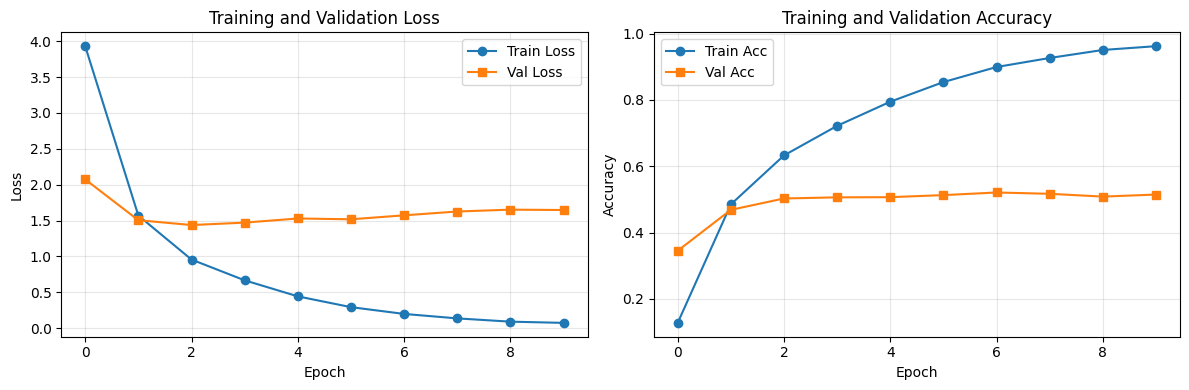

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accs, label='Train Acc', marker='o')
axes[1].plot(val_accs, label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

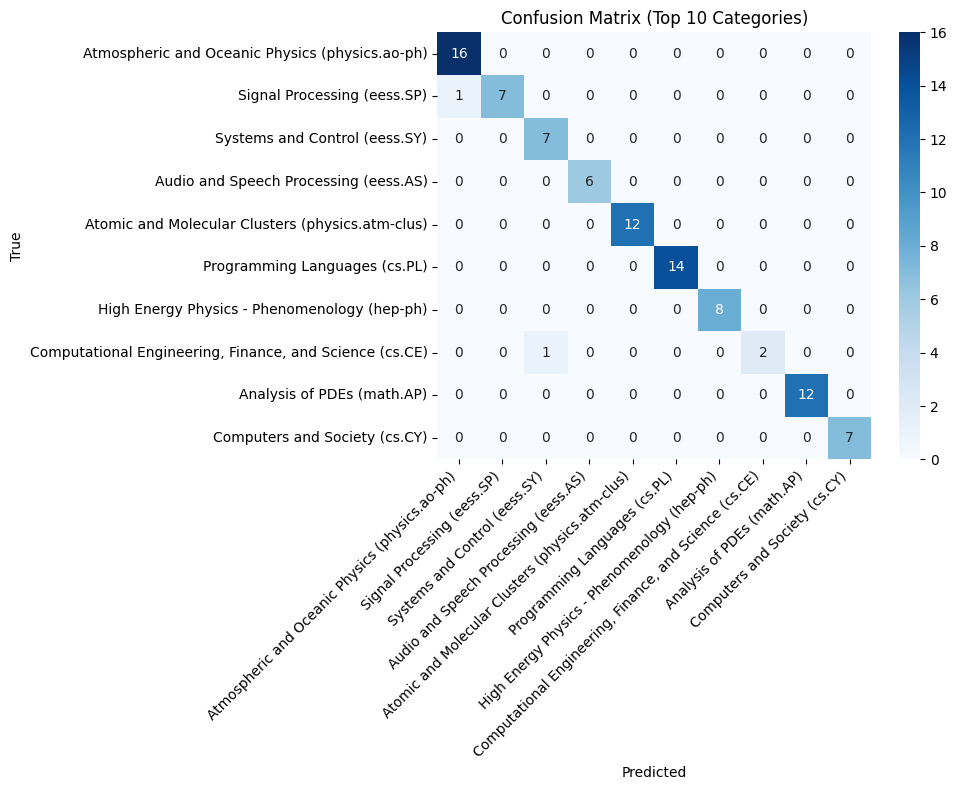

In [18]:
# Confusion matrix for top categories
from sklearn.metrics import confusion_matrix

# Get top 10 most frequent categories for visualization
top_categories = df_balanced['category'].value_counts().head(10).index.tolist()
mask = [cat in top_categories for cat in true_categories]

filtered_true = [cat for cat, m in zip(true_categories, mask) if m]
filtered_pred = [cat for cat, m in zip(predicted_categories, mask) if m]

if len(filtered_true) > 0:
    cm = confusion_matrix(filtered_true, filtered_pred, labels=top_categories)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=top_categories, yticklabels=top_categories)
    plt.title('Confusion Matrix (Top 10 Categories)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 8. Error Analysis and Label Cleaning

In [19]:
def analyze_errors(model, dataloader, tokenizer, label_encoder, num_examples=5):
    """Analyze misclassified examples"""
    model.eval()
    errors = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            probs = F.softmax(logits, dim=-1)
            _, predicted = torch.max(logits, 1)
            
            # Find misclassified examples
            misclassified = (predicted != labels).cpu().numpy()
            
            for idx in np.where(misclassified)[0]:
                # Decode text
                text = tokenizer.decode(input_ids[idx], skip_special_tokens=True)
                true_label = label_encoder.inverse_transform([labels[idx].cpu().item()])[0]
                pred_label = label_encoder.inverse_transform([predicted[idx].cpu().item()])[0]
                confidence = probs[idx][predicted[idx]].cpu().item()
                
                errors.append({
    'text': text[:200] + '...' if len(text) > 200 else text,
                    'true_label': true_label,
                    'predicted_label': pred_label,
                    'confidence': confidence
                })
    
    # Sort by confidence (low confidence = likely mislabeled)
    errors.sort(key=lambda x: x['confidence'])
    
    print("\nTop Misclassified Examples (Low Confidence):")
    print("="*80)
    for i, error in enumerate(errors[:num_examples]):
        print(f"\nExample {i+1}:")
        print(f"Text: {error['text']}")
        print(f"True Label: {error['true_label']}")
        print(f"Predicted: {error['predicted_label']} (Confidence: {error['confidence']:.3f})")
        print("-"*40)
    
    return errors

# Analyze errors
errors = analyze_errors(model, test_loader, tokenizer, label_encoder)


Top Misclassified Examples (Low Confidence):

Example 1:
Text: the laplace operator encodes the behavior of physical systems at vastly different scales, describing heat flow, fluids, as well as electric, gravitational, and quantum fields. a key input for the lapl...
True Label: Other Condensed Matter (cond-mat.other)
Predicted: Disordered Systems and Neural Networks (cond-mat.dis-nn) (Confidence: 0.088)
----------------------------------------

Example 2:
Text: relative compression, where a set of similar strings are compressed with respect to a reference string, is a very effective method of compressing dna datasets containing multiple similar sequences. re...
True Label: Quantitative Methods (q-bio.QM)
Predicted: Information Theory (cs.IT) (Confidence: 0.130)
----------------------------------------

Example 3:
Text: here i investigate some mathematical aspects of the maximum entropy theory of ecology ( mete ). in particular i address the geometrical structure of mete endowed by inf

In [20]:
# Identify potentially mislabeled data using confidence scores
def find_label_issues(model, dataloader, threshold=0.3):
    """Find potential label issues based on prediction confidence"""
    model.eval()
    label_issues = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            probs = F.softmax(logits, dim=-1)
            
            # Get confidence for the true label
            true_label_probs = probs[range(len(labels)), labels]
            
            # Find examples where model has low confidence in true label
            low_confidence_mask = true_label_probs < threshold
            
            for idx in torch.where(low_confidence_mask)[0]:
                label_issues.append({
                    'confidence': true_label_probs[idx].item(),
                    'true_label': labels[idx].item(),
                    'predicted_label': torch.argmax(probs[idx]).item(),
                    'pred_confidence': torch.max(probs[idx]).item()
                })
    
    return label_issues

# Find potential label issues
label_issues = find_label_issues(model, train_loader, threshold=0.3)
print(f"\nFound {len(label_issues)} potential label issues (confidence < 0.3)")

if len(label_issues) > 0:
    issue_df = pd.DataFrame(label_issues)
    print("\nLabel Issue Statistics:")
    print(issue_df.describe())


Found 368 potential label issues (confidence < 0.3)

Label Issue Statistics:
       confidence  true_label  predicted_label  pred_confidence
count  368.000000  368.000000       368.000000       368.000000
mean     0.137862   71.625000        77.964674         0.548003
std      0.093623   45.025704        43.725941         0.196309
min      0.000033    0.000000         1.000000         0.150831
25%      0.054967   31.000000        40.250000         0.383056
50%      0.139496   73.000000        84.500000         0.553518
75%      0.218588  110.250000       115.250000         0.685436
max      0.299657  147.000000       147.000000         0.972884


## 9. Performance Summary and Recommendations

In [21]:
# Calculate per-category performance
category_performance = []
for category in label_encoder.classes_:
    mask = true_categories == category
    if np.any(mask):
        cat_true = np.array(true_categories)[mask]
        cat_pred = np.array(predicted_categories)[mask]
        acc = accuracy_score(cat_true, cat_pred)
        category_performance.append({
            'category': category,
            'accuracy': acc,
            'support': len(cat_true)
        })

perf_df = pd.DataFrame(category_performance).sort_values('accuracy')

print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"\nOverall Test Accuracy: {test_acc:.2%}")
print(f"Number of Categories: {num_classes}")
print(f"\nWorst Performing Categories:")
print(perf_df.head(5).to_string(index=False))
print(f"\nBest Performing Categories:")
print(perf_df.tail(5).to_string(index=False))


PERFORMANCE SUMMARY

Overall Test Accuracy: 53.55%
Number of Categories: 148

Worst Performing Categories:
                                               category  accuracy  support
Computational Engineering, Finance, and Science (cs.CE)      0.10       20
                        Quantitative Methods (q-bio.QM)      0.10       20
                        Artificial Intelligence (cs.AI)      0.15       20
   Distributed, Parallel, and Cluster Computing (cs.DC)      0.15       20
                         Other Computer Science (cs.OH)      0.15       20

Best Performing Categories:
                                      category  accuracy  support
Earth and Planetary Astrophysics (astro-ph.EP)      0.80       20
     High Energy Physics - Experiment (hep-ex)      0.85       20
                     Operating Systems (cs.OS)      0.85       20
             Plasma Physics (physics.plasm-ph)      0.95       20
         Superconductivity (cond-mat.supr-con)      0.95       20


In [22]:
print("\n" + "="*80)
print("RECOMMENDATIONS FOR FURTHER IMPROVEMENT")
print("="*80)

recommendations = [
    "1. Data Quality:",
    f"   - Found {len(label_issues)} potential mislabeled examples",
    "   - Consider manual review of low-confidence predictions",
    "   - Clean dataset using the identified label issues",
    "",
    "2. Class Imbalance:",
    f"   - Current accuracy: {test_acc:.2%}",
    "   - Consider hierarchical classification for related categories",
    "   - Use data augmentation for underrepresented classes",
    "",
    "3. Model Architecture:",
    "   - Try ensemble methods (combine multiple models)",
    "   - Experiment with larger models (DeBERTa-v3-large)",
    "   - Use contrastive learning for better representations",
    "",
    "4. Training Strategy:",
    "   - Implement curriculum learning (easy to hard examples)",
    "   - Try different loss functions (ArcFace, CosFace)",
    "   - Use pseudo-labeling on unlabeled data if available",
    "",
    "5. Category Reduction:",
    f"   - Current categories: {num_classes}",
    "   - Group similar categories semantically",
    "   - Focus on categories with >100 samples for production"
]

for line in recommendations:
    print(line)

# Save results
results = {
    'test_accuracy': test_acc,
    'num_classes': num_classes,
    'model_name': MODEL_NAME,
    'best_val_accuracy': best_val_acc,
    'label_issues_found': len(label_issues)
}

import json
with open('classification_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✓ Results saved to classification_results.json")


RECOMMENDATIONS FOR FURTHER IMPROVEMENT
1. Data Quality:
   - Found 368 potential mislabeled examples
   - Consider manual review of low-confidence predictions
   - Clean dataset using the identified label issues

2. Class Imbalance:
   - Current accuracy: 53.55%
   - Consider hierarchical classification for related categories
   - Use data augmentation for underrepresented classes

3. Model Architecture:
   - Try ensemble methods (combine multiple models)
   - Experiment with larger models (DeBERTa-v3-large)
   - Use contrastive learning for better representations

4. Training Strategy:
   - Implement curriculum learning (easy to hard examples)
   - Try different loss functions (ArcFace, CosFace)
   - Use pseudo-labeling on unlabeled data if available

5. Category Reduction:
   - Current categories: 148
   - Group similar categories semantically
   - Focus on categories with >100 samples for production

✓ Results saved to classification_results.json
